# 02 — Data Collection

Harvest destinasi wisata Jakarta dari OpenStreetMap (Overpass API).
Sumber: legal, gratis, lisensi ODbL. Bukan scraping TripAdvisor.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import config

## Konfigurasi area & filter kategori

In [2]:
print("Boundary area:", config.JAKARTA_AREA_NAME, "(admin_level", config.JAKARTA_AREA_ADMIN_LEVEL, ")")
print("Bbox fallback:", config.JAKARTA_BBOX)
print()
print("Filter kategori wisata:")
for k, v in config.TOURISM_FILTERS.items():
    print(f"  {k}: {v}")

Boundary area: Daerah Khusus Ibukota Jakarta (admin_level 4 )
Bbox fallback: (-6.4, 106.65, -6.08, 107.0)

Filter kategori wisata:
  tourism: ['attraction', 'museum', 'viewpoint', 'zoo', 'theme_park', 'gallery', 'artwork', 'aquarium']
  leisure: ['park', 'garden']
  historic: None
  amenity: ['place_of_worship', 'marketplace']


## Jalankan harvest

Uncomment baris di bawah untuk re-run collect (butuh internet, ~2-3 menit).
Kalau hanya mau lihat hasil run sebelumnya, skip ke section berikutnya.

In [3]:
# import collect
# collect.main()

## Hasil: data/venues_raw.csv

In [4]:
raw = pd.read_csv("../../data/venues_raw.csv")
print(f"Total venue: {len(raw)}")
raw.head(10)

Total venue: 6166


,venue_id,name,venue_category,latitude,longitude,opening_hours,website,wikipedia,wikidata,osm_url,maps_url
0,way/28845528,Taman Impian Jaya Ancol,tourism:theme_park,-6.121603,106.845283,NaN,https://www.ancol.com/,id:Taman Impian Jaya Ancol,Q3270617,https://www.openstreetmap.org/way/28845528,https://www.google.com/maps/search/?api=1&quer...
1,node/316613327,Art & Craft Market,tourism:attraction,-6.126570,106.839134,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/316613327,https://www.google.com/maps/search/?api=1&quer...
2,node/359852056,Wayang Museum,tourism:museum,-6.134815,106.812509,Tu-Su 09:00-16:30,NaN,en:Wayang Museum,Q2854954,https://www.openstreetmap.org/node/359852056,https://www.google.com/maps/search/?api=1&quer...
3,node/1699892511,Rizel Art,tourism:artwork,-5.738238,106.601025,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/1699892511,https://www.google.com/maps/search/?api=1&quer...
4,node/1699892548,Tas dari Daur Ulang Sampah,tourism:artwork,-5.738389,106.600869,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/1699892548,https://www.google.com/maps/search/?api=1&quer...
5,node/1707153377,Rumah Daur Ulang,tourism:artwork,-5.744803,106.614677,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/1707153377,https://www.google.com/maps/search/?api=1&quer...
6,node/2132034785,Diving Spot,tourism:attraction,-5.737426,106.614801,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/2132034785,https://www.google.com/maps/search/?api=1&quer...
7,node/2132034786,Diving Spot,tourism:attraction,-5.738186,106.590903,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/2132034786,https://www.google.com/maps/search/?api=1&quer...
8,node/2132034789,Diving Spot,tourism:attraction,-5.745788,106.589205,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/2132034789,https://www.google.com/maps/search/?api=1&quer...
9,node/2132034790,Diving Spot,tourism:attraction,-5.747815,106.601812,NaN,NaN,NaN,NaN,https://www.openstreetmap.org/node/2132034790,https://www.google.com/maps/search/?api=1&quer...


## Distribusi kategori

In [5]:
raw["venue_category"].value_counts().head(15)

venue_category
amenity:place_of_worship    5323
leisure:park                 392
amenity:marketplace          229
tourism:museum                39
tourism:attraction            37
tourism:artwork               24
historic:memorial             24
tourism:gallery               18
historic:monument             17
tourism:viewpoint             13
leisure:garden                11
historic:building              8
tourism:theme_park             7
tourism:zoo                    5
tourism:yes                    3
Name: count, dtype: int64

## Sebaran geografis (sanity check boundary)

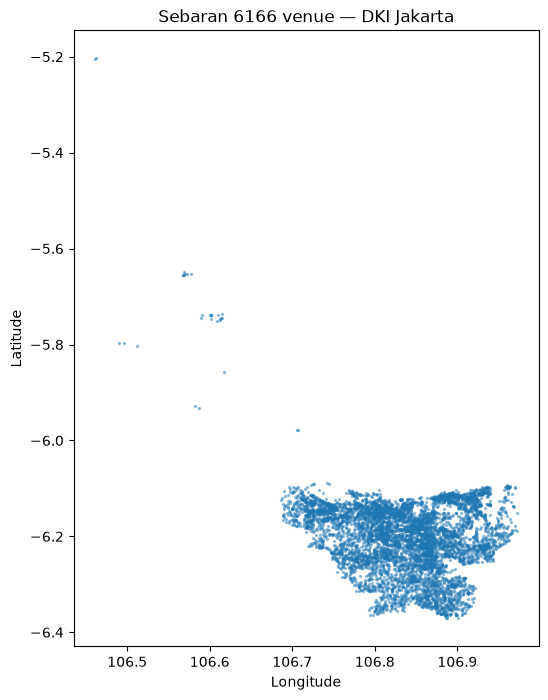

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(raw["longitude"], raw["latitude"], s=2, alpha=0.4)
ax.set_title(f"Sebaran {len(raw)} venue — DKI Jakarta")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()